In [ ]:
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt
from sklearn import datasets
import pandas as pd

In [4]:
data = pd.read_csv('../input/social-network-ads/Social_Network_Ads.csv')
X=data.iloc[:,2:4]
y=data['Purchased']
data.head()


,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0


In [5]:
data.Gender.replace(['Female','Male'],[0,1],inplace=True)

In [6]:
data.head()

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,1,19,19000,0
1,15810944,1,35,20000,0
2,15668575,0,26,43000,0
3,15603246,0,27,57000,0
4,15804002,1,19,76000,0


In [7]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2,random_state=1)

In [8]:
model = tf.keras.models.Sequential()
model.add(tf.keras.layers.Reshape((2,),input_shape=(2,)))
#Normalize the data
model.add(tf.keras.layers.BatchNormalization())


User settings:

   KMP_AFFINITY=granularity=fine,verbose,compact,1,0
   KMP_BLOCKTIME=0
   KMP_DUPLICATE_LIB_OK=True
   KMP_INIT_AT_FORK=FALSE
   KMP_SETTINGS=1
   KMP_WARNINGS=0

Effective settings:

   KMP_ABORT_DELAY=0
   KMP_ADAPTIVE_LOCK_PROPS='1,1024'
   KMP_ALIGN_ALLOC=64
   KMP_ALL_THREADPRIVATE=128
   KMP_ATOMIC_MODE=2
   KMP_BLOCKTIME=0
   KMP_CPUINFO_FILE: value is not defined
   KMP_DETERMINISTIC_REDUCTION=false
   KMP_DEVICE_THREAD_LIMIT=2147483647
   KMP_DISP_NUM_BUFFERS=7
   KMP_DUPLICATE_LIB_OK=true
   KMP_ENABLE_TASK_THROTTLING=true
   KMP_FORCE_REDUCTION: value is not defined
   KMP_FOREIGN_THREADS_THREADPRIVATE=true
   KMP_FORKJOIN_BARRIER='2,2'
   KMP_FORKJOIN_BARRIER_PATTERN='hyper,hyper'
   KMP_GTID_MODE=3
   KMP_HANDLE_SIGNALS=false
   KMP_HOT_TEAMS_MAX_LEVEL=1
   KMP_HOT_TEAMS_MODE=0
   KMP_INIT_AT_FORK=true
   KMP_LIBRARY=throughput
   KMP_LOCK_KIND=queuing
   KMP_MALLOC_POOL_INCR=1M
   KMP_NUM_LOCKS_IN_BLOCK=1
   KMP_PLAIN_BARRIER='2,2'
   KMP_PLAIN_BARRIER_P

In [9]:
model.add(tf.keras.layers.Dense(500, activation='relu'))
model.add(tf.keras.layers.BatchNormalization())

In [10]:
#Add 1st hidden layer
model.add(tf.keras.layers.Dense(200, activation='relu'))
model.add(tf.keras.layers.BatchNormalization())

In [11]:
#Add 2nd hidden layer
model.add(tf.keras.layers.Dense(100, activation='relu'))
model.add(tf.keras.layers.BatchNormalization())

In [12]:
#Add 3rd hidden layer
model.add(tf.keras.layers.Dense(60, activation='relu'))
model.add(tf.keras.layers.BatchNormalization())

In [13]:
#Add 4th hidden layer
model.add(tf.keras.layers.Dense(30, activation='relu'))
model.add(tf.keras.layers.BatchNormalization())

In [14]:
#Add OUTPUT layer
model.add(tf.keras.layers.Dense(1, activation='sigmoid'))

In [15]:
#Stochaistic Gradient 
sgd_optimizer = tf.keras.optimizers.SGD(lr=0.01)

#Compile the model
model.compile(optimizer=sgd_optimizer, loss='binary_crossentropy', metrics=['accuracy'])

/opt/conda/lib/python3.7/site-packages/keras/optimizer_v2/optimizer_v2.py:356: UserWarning: The `lr` argument is deprecated, use `learning_rate` instead.
  "The `lr` argument is deprecated, use `learning_rate` instead.")


In [16]:
model.fit(X_train,y_train,          
          validation_data=(X_test,y_test),
          epochs=100,
          batch_size=32)

2022-01-04 20:11:08.365113: I tensorflow/compiler/mlir/mlir_graph_optimization_pass.cc:185] None of the MLIR Optimization Passes are enabled (registered 2)


Epoch 1/100
10/10 [==============================] - 2s 47ms/step - loss: 0.4340 - accuracy: 0.8125 - val_loss: 0.7463 - val_accuracy: 0.4000
Epoch 2/100
10/10 [==============================] - 0s 8ms/step - loss: 0.3328 - accuracy: 0.8938 - val_loss: 0.7069 - val_accuracy: 0.4000
Epoch 3/100
10/10 [==============================] - 0s 8ms/step - loss: 0.2896 - accuracy: 0.9062 - val_loss: 0.6757 - val_accuracy: 0.5000
Epoch 4/100
10/10 [==============================] - 0s 14ms/step - loss: 0.3396 - accuracy: 0.8719 - val_loss: 0.6487 - val_accuracy: 0.6750
Epoch 5/100
10/10 [==============================] - 0s 8ms/step - loss: 0.3006 - accuracy: 0.8969 - val_loss: 0.6280 - val_accuracy: 0.8125
Epoch 6/100
10/10 [==============================] - 0s 8ms/step - loss: 0.2841 - accuracy: 0.9094 - val_loss: 0.6109 - val_accuracy: 0.8125
Epoch 7/100
10/10 [==============================] - 0s 8ms/step - loss: 0.2798 - accuracy: 0.9281 - val_loss: 0.6077 - val_accuracy: 0.7000
Epoch 8/100

In [17]:
model.summary()

Model: "sequential"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
reshape (Reshape)            (None, 2)                 0         
_________________________________________________________________
batch_normalization (BatchNo (None, 2)                 8         
_________________________________________________________________
dense (Dense)                (None, 500)               1500      
_________________________________________________________________
batch_normalization_1 (Batch (None, 500)               2000      
_________________________________________________________________
dense_1 (Dense)              (None, 200)               100200    
_________________________________________________________________
batch_normalization_2 (Batch (None, 200)               800       
_________________________________________________________________
dense_2 (Dense)              (None, 100)               2

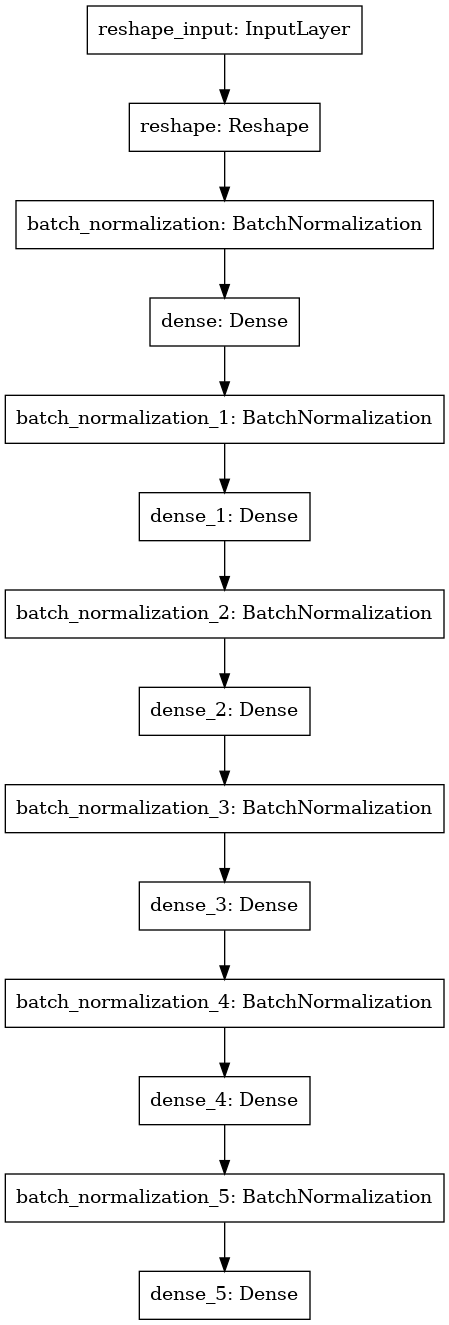

In [18]:
tf.keras.utils.plot_model(model)